In [1]:
import pandas as pd

In [2]:
master = pd.read_csv("../data/cleaned/master_dataset.csv")

In [3]:
customer_metrics = (
    master
    .groupby("customer_unique_id")
    .agg(
        {
            "order_id":"nunique",
            "revenue":"sum"
        }
    )
    .reset_index()
)

customer_metrics.columns = [
    "customer_unique_id",
    "number_of_orders",
    "total_revenue"
]

In [4]:
customer_metrics.head()

,customer_unique_id,number_of_orders,total_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [5]:
customer_metrics["average_order_value"] = (
    customer_metrics["total_revenue"]
    /
    customer_metrics["number_of_orders"]
)

In [6]:
master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

days = (
    master["order_purchase_timestamp"].max()
    -
    master["order_purchase_timestamp"].min()
).days

days

772

In [7]:
customer_metrics["purchase_frequency"] = (
    customer_metrics["number_of_orders"]
    /
    days
)

In [8]:
customer_metrics["CLV"] = (
    customer_metrics["average_order_value"]
    *
    customer_metrics["purchase_frequency"]
    *
    365
)

In [9]:
customer_metrics.sort_values(
    "CLV",
    ascending=False
).head(10)

,customer_unique_id,number_of_orders,total_revenue,average_order_value,purchase_frequency,CLV
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,0.001295,6460.348705
52175,8af7ac63b2efbcbd88e5b11505e8098a,1,13281.71,13281.710,0.001295,6279.564961
73922,c4b224d2c784bae11ae98b6ae9f2454c,1,11111.40,11111.400,0.001295,5253.446891
50192,85963fd37bfd387aa6d915d8a1065486,1,10553.28,10553.280,0.001295,4989.568912
71593,be74c431147c32ab2d7c7cef5e4a995f,1,10055.22,10055.220,0.001295,4754.087176
89420,edf81e1f3070b9dac83ec83dacdbb9bc,1,8389.52,8389.520,0.001295,3966.547668
33244,58483a1c055dfb600f57c5b867174542,1,8068.88,8068.880,0.001295,3814.949741
6132,1033eef37a760a832f9b2332ce23fdc5,1,8030.46,8030.460,0.001295,3796.784845
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,0.002591,3579.850972
18139,301d1ce5a76b7e1bc47e5115bf5eb6ba,1,7413.70,7413.700,0.001295,3505.181995


In [10]:
customer_metrics["CLV"].describe()

count    96096.000000
mean        81.888129
std        124.889764
min          0.000000
25%         29.913925
50%         51.922668
75%         88.980570
max       6460.348705
Name: CLV, dtype: float64

In [11]:
customer_metrics["CLV_Segment"] = pd.qcut(
    customer_metrics["CLV"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

In [16]:
customer_metrics["CLV_Segment"].value_counts()

CLV_Segment
Low Value       24055
High Value      24026
VIP             24020
Medium Value    23995
Name: count, dtype: int64

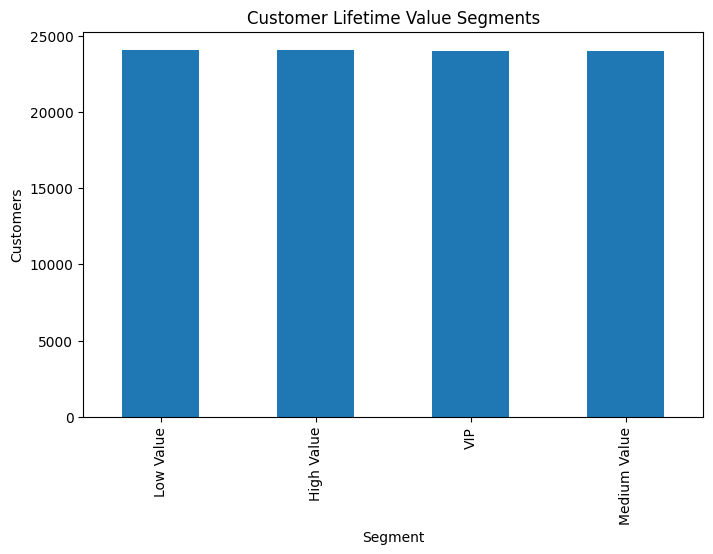

In [13]:
import matplotlib.pyplot as plt

customer_metrics["CLV_Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Lifetime Value Segments")
plt.xlabel("Segment")
plt.ylabel("Customers")

plt.show()

In [14]:
customer_metrics.sort_values(
    "CLV",
    ascending=False
).head(10)

,customer_unique_id,number_of_orders,total_revenue,average_order_value,purchase_frequency,CLV,CLV_Segment
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,0.001295,6460.348705,VIP
52175,8af7ac63b2efbcbd88e5b11505e8098a,1,13281.71,13281.710,0.001295,6279.564961,VIP
73922,c4b224d2c784bae11ae98b6ae9f2454c,1,11111.40,11111.400,0.001295,5253.446891,VIP
50192,85963fd37bfd387aa6d915d8a1065486,1,10553.28,10553.280,0.001295,4989.568912,VIP
71593,be74c431147c32ab2d7c7cef5e4a995f,1,10055.22,10055.220,0.001295,4754.087176,VIP
89420,edf81e1f3070b9dac83ec83dacdbb9bc,1,8389.52,8389.520,0.001295,3966.547668,VIP
33244,58483a1c055dfb600f57c5b867174542,1,8068.88,8068.880,0.001295,3814.949741,VIP
6132,1033eef37a760a832f9b2332ce23fdc5,1,8030.46,8030.460,0.001295,3796.784845,VIP
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,0.002591,3579.850972,VIP
18139,301d1ce5a76b7e1bc47e5115bf5eb6ba,1,7413.70,7413.700,0.001295,3505.181995,VIP


In [15]:
customer_metrics.to_csv(
    "../data/cleaned/customer_clv.csv",
    index=False
)